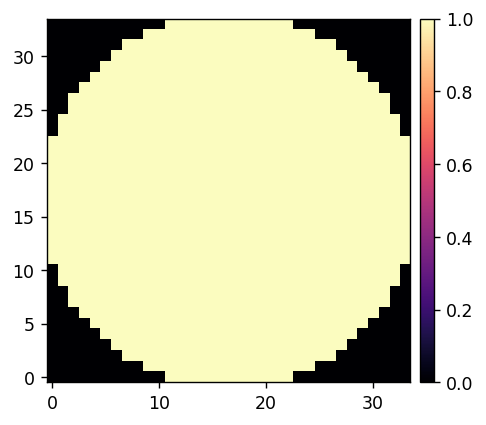

ERROR:purepyindi2.transports:Connection failed. Reconnecting to localhost:7624 in 2 sec...
ERROR:purepyindi2.transports:Failed to connect to localhost:7624
Traceback (most recent call last):
  File "/opt/MagAOX/source/purepyindi2/purepyindi2/transports.py", line 154, in _reconnection_monitor
    self._socket.connect((self.host, self.port))
ConnectionRefusedError: [Errno 111] Connection refused
INFO:purepyindi2.transports:Retrying in 2 sec...
ERROR:purepyindi2.transports:Failed to connect to localhost:7624
Traceback (most recent call last):
  File "/opt/MagAOX/source/purepyindi2/purepyindi2/transports.py", line 154, in _reconnection_monitor
    self._socket.connect((self.host, self.port))
ConnectionRefusedError: [Errno 111] Connection refused
INFO:purepyindi2.transports:Retrying in 2 sec...
ERROR:purepyindi2.transports:Failed to connect to localhost:7624
Traceback (most recent call last):
  File "/opt/MagAOX/source/purepyindi2/purepyindi2/transports.py", line 154, in _reconnection_monit

In [ ]:
import numpy as np
import astropy.units as u
import threading as th
import time 
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from IPython.display import clear_output
from importlib import reload
import copy
import os
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle

import scoob_llowfsc
from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc import utils
from scoob_llowfsc import dm
from scoob_llowfsc import telem
import scoob_llowfsc.scoob_interface as scoobi
from scoob_llowfsc import llowfsc

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient
client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

def restart_clients():
    client0 = INDIClient('localhost', 7624)
    client0.start()
    client = IndiClient()
    client.connect()
    client.get_properties()

wavelength = 633e-9

wavelength_c = 633e-9
camsci_pxscl = 4.6e-6
camsci_pxscl_lamDc = 0.307

dm_mask = ensure_np_array(dm.make_mask(34))
utils.imshow([dm_mask])

data_path = scoob_llowfsc.path/'exp-data'


# Setup SHMIM names and directory paths.

In [ ]:
camsci_name = 'camlo'
camlo_name = 'camsci'
dm_wfe_name = 'dm00disp01'
dm_lo_name = 'dm00disp02'
dm_ho_name = 'dm00disp03'

camlo_ref_name = 'camlo_ref_0'
camlo_ref_offset_name = 'camlo_ref_offset'

camsci_rawims_path = Path(f'/opt/MagAOX/rawimages/{camsci_name}/')
camlo_rawims_path = Path(f'/opt/MagAOX/rawimages/{camlo_name}/')
camlo_ref_rawims_path = Path(f'/opt/MagAOX/rawimages/{camlo_ref_name}/')
camlo_ref_offset_rawims_path = Path(f'/opt/MagAOX/rawimages/{camlo_ref_offset_name}/')
dm_wfe_rawims_path = Path(f'/opt/MagAOX/rawimages/{dm_wfe_name}/')
dm_lo_rawims_path = Path(f'/opt/MagAOX/rawimages/{dm_lo_name}/')
dm_ho_rawims_path = Path(f'/opt/MagAOX/rawimages/{dm_ho_name}/')

# date = 20250409
# date = 20250410
date = today
exp_path = data_path/f'exp-{date}'
llowfsc_data_path = data_path/f'exp-{today}'/'llowfsc'
telem_data_path = data_path/f'exp-{date}'/'raw-telem'
unpacked_data_path = data_path/f'exp-{date}'/'unpacked-telem'

In [ ]:
telem.make_dir(exp_path)
telem.make_dir(llowfsc_data_path)
telem.make_dir(telem_data_path)
telem.make_dir(unpacked_data_path)

# Delete old telemetry data if needed. I assume the old data has already been moved to somewhere safe if it was important.

In [ ]:
reload(telem)
telem.delete_files(camsci_rawims_path/'*.xrif')
telem.delete_files(camlo_rawims_path/'*.xrif')
telem.delete_files(camlo_ref_rawims_path/'*.xrif')
telem.delete_files(camlo_ref_offset_rawims_path/'*.xrif')
telem.delete_files(dm_wfe_rawims_path/'*.xrif')
telem.delete_files(dm_lo_rawims_path/'*.xrif')
telem.delete_files(dm_ho_rawims_path/'*.xrif')

telem.delete_files(telem_data_path/'*')
telem.delete_files(unpacked_data_path/'*')

# Set CAMLO ROI.

In [ ]:
reload(scoobi)
xc, yc = (3725, 2500)
npsf = 128
scoobi.set_cam_roi(xc, yc, npsf, client0, cam_name=camlo_name, bin_mode=2)
scoobi.set_cam_exp_time(0.001, client0, cam_name=camlo_name,)
scoobi.set_cam_gain(120, client0, cam_name=camlo_name,)
scoobi.set_cam_blacklevel(2, client0, cam_name=camlo_name,)

# Setup the CAMLO, DM, and LLOWFSC reference streams.

In [ ]:
camlo_stream = ImageStream(camlo_name)
dm_lo_stream = ImageStream(dm_lo_name)
dm_ho_stream = ImageStream(dm_ho_name)


In [ ]:
camlo_dims = camlo_stream.shape[:-1]
print(camlo_dims)

scoobi.create_shmim(camlo_ref_name, camlo_dims)
scoobi.create_shmim(camlo_ref_offset_name, camlo_dims)

camlo_ref_stream = ImageStream(camlo_ref_name)
camlo_ref_offset_stream = ImageStream(camlo_ref_offset_name)

# Initialize streams and create required shmims.

0


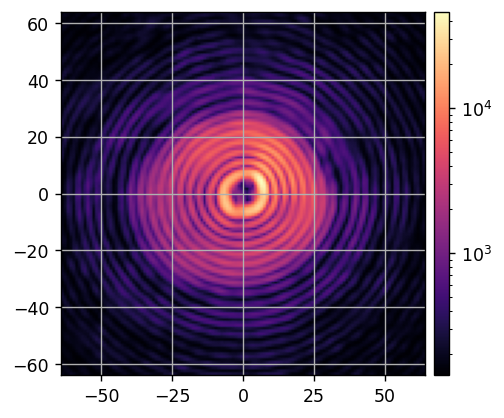

In [ ]:
ref_im = scoobi.snap(camlo_stream, 100)
utils.imshow([ref_im], grids=[1], pxscls=[1], norms=[LogNorm()], cmaps=['magma'])

1


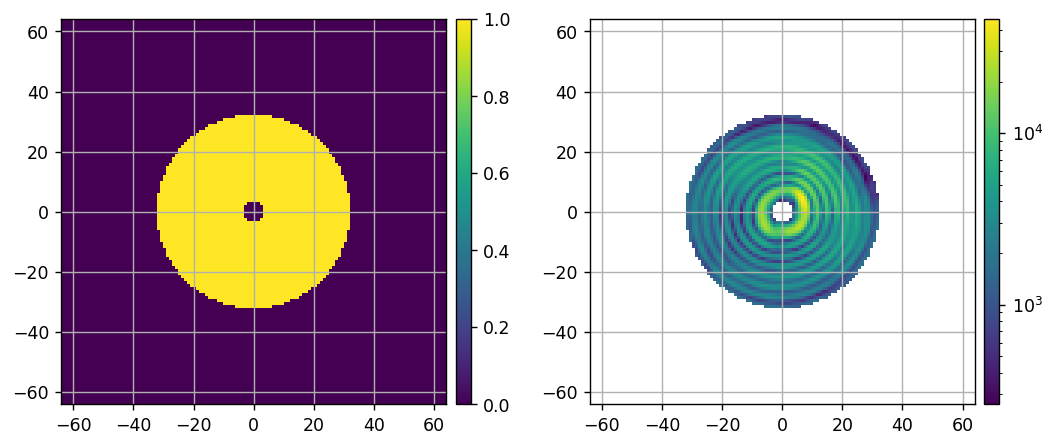

In [ ]:
irad = 3
orad = 32
control_mask = llowfsc.create_control_mask(
    camlo_dims, 
    irad, 
    orad, 
    x_shift=0,
    y_shift=0,
    even=1,
)
# control_mask = xp.ones((M.nlocam, M.nlocam)).astype(bool)
utils.imshow([control_mask, ref_im * control_mask], grids=[1, 1], pxscls=[1, 1], norms=[None, LogNorm()])

In [26]:
camlo_ref_stream.write(ref_im*control_mask)

# Calibrate LLOWFSC with the Zernike modes we want to control

1


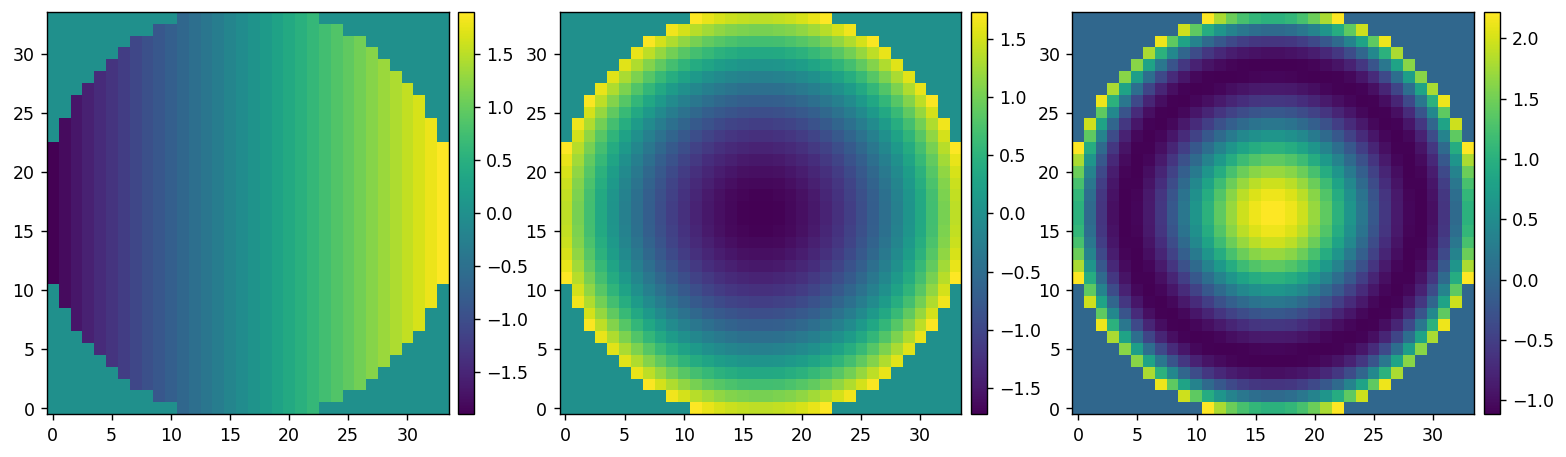

In [ ]:
reload(scoobi)
reload(utils)
Nz_modes = 10
zer_modes = ensure_np_array(utils.create_zernike_modes(dm_mask, nmodes=Nz_modes, remove_modes=1))
zer_modal_matrix = zer_modes.reshape(Nz_modes, -1)
utils.imshow([zer_modes[0], zer_modes[2], zer_modes[-1]])

1


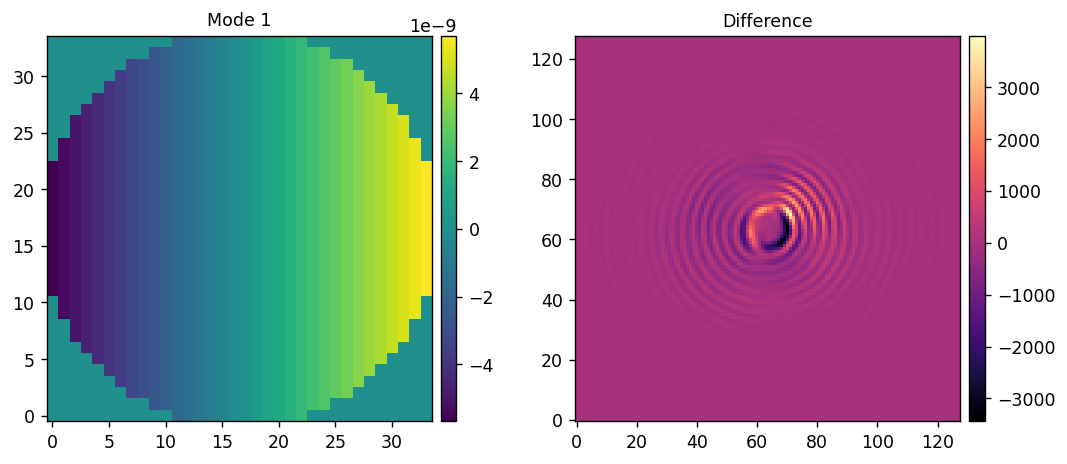

1Calibrated mode 1/10 in 4.979s


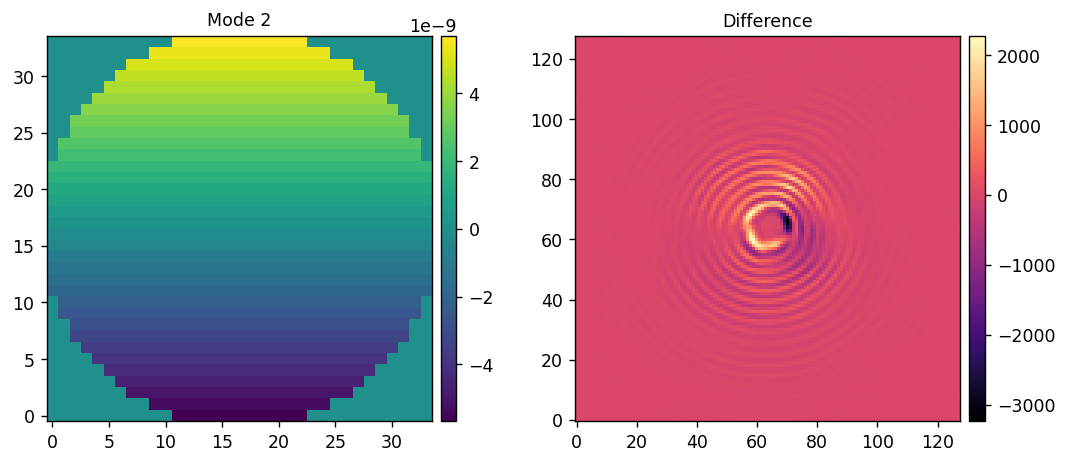

1Calibrated mode 2/10 in 10.121s


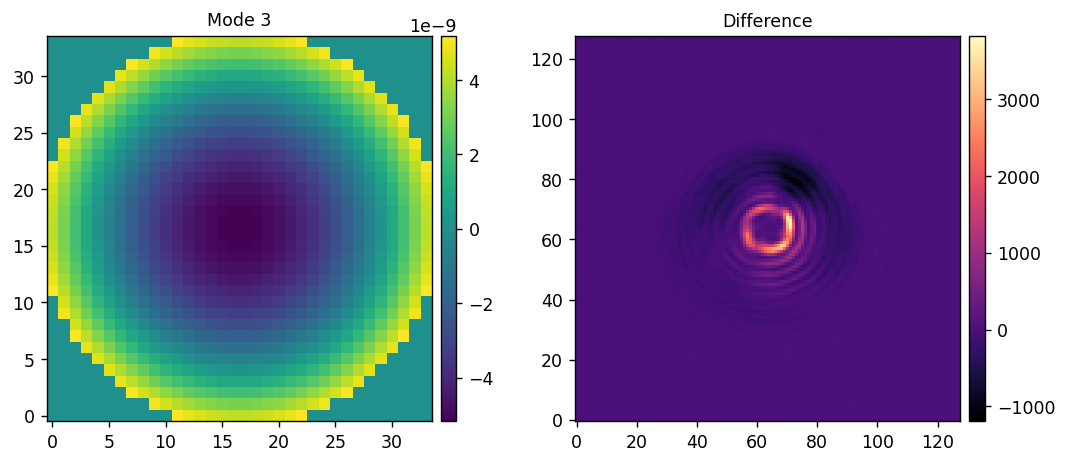

1Calibrated mode 3/10 in 15.179s


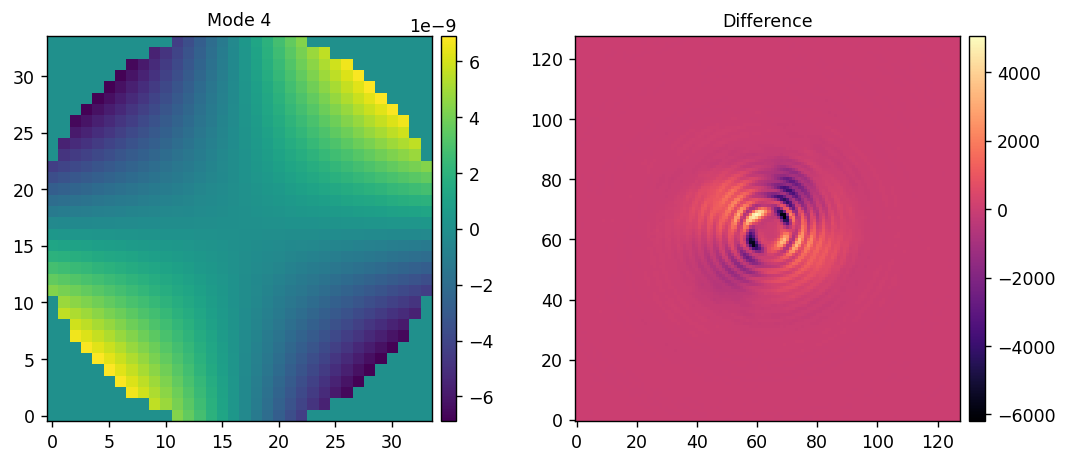

1Calibrated mode 4/10 in 20.375s


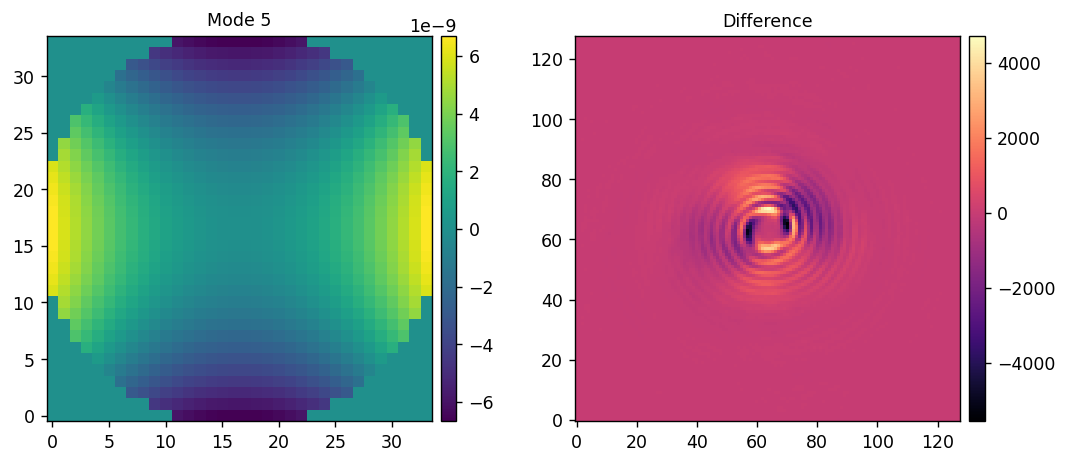

1Calibrated mode 5/10 in 25.257s


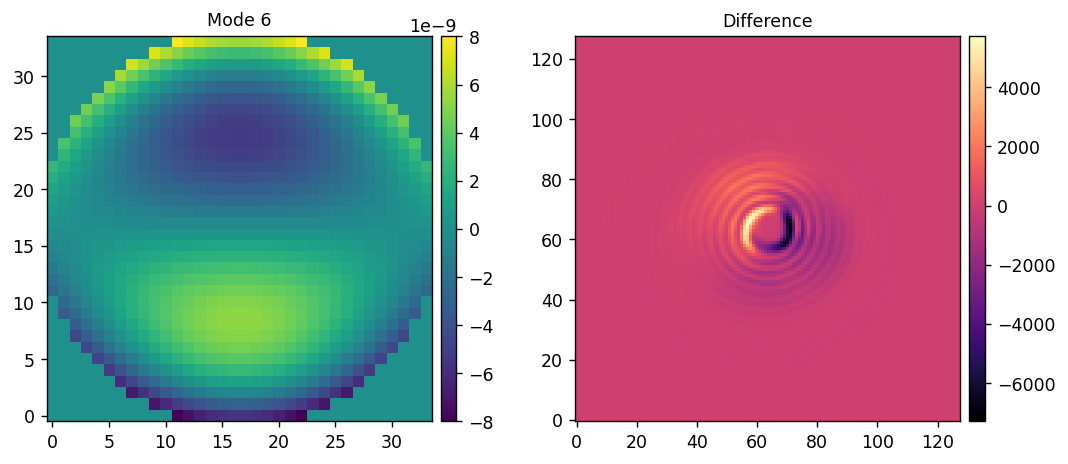

1Calibrated mode 6/10 in 30.541s


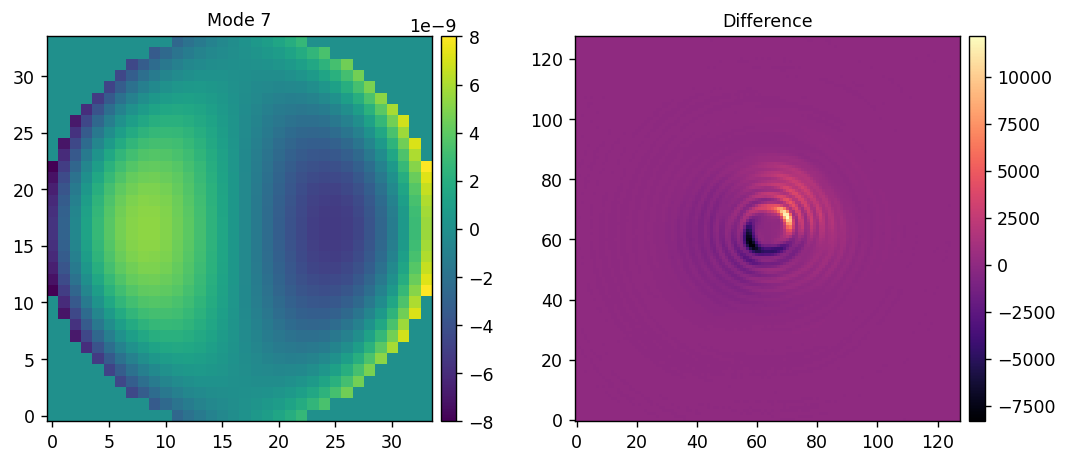

1Calibrated mode 7/10 in 35.515s


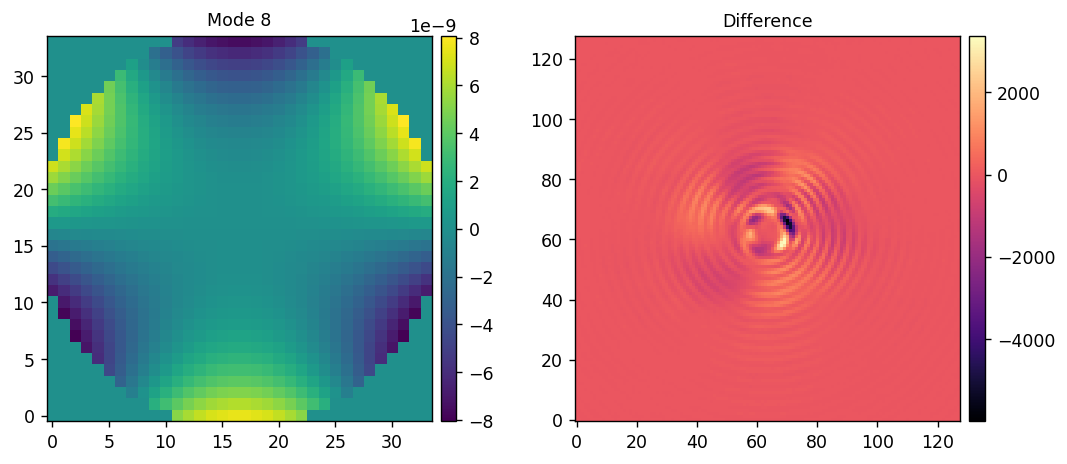

1Calibrated mode 8/10 in 40.418s


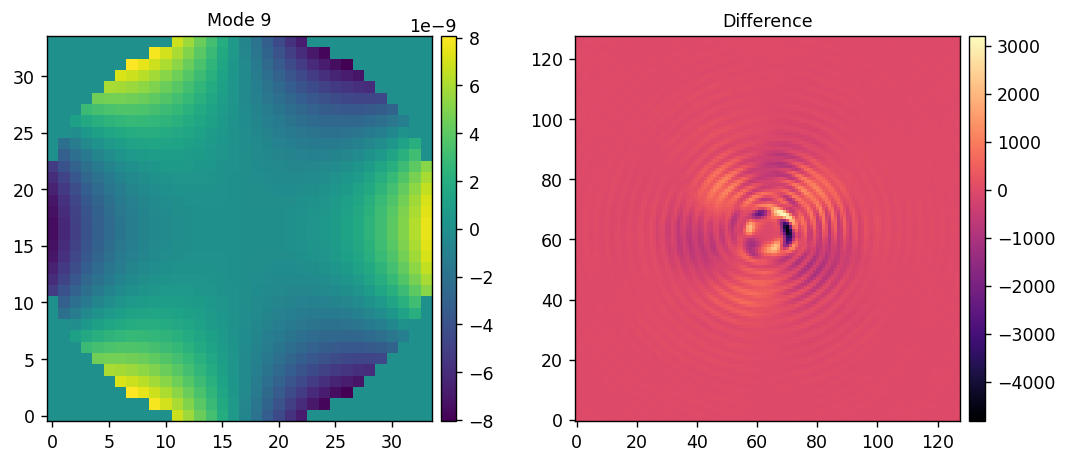

1Calibrated mode 9/10 in 45.230s


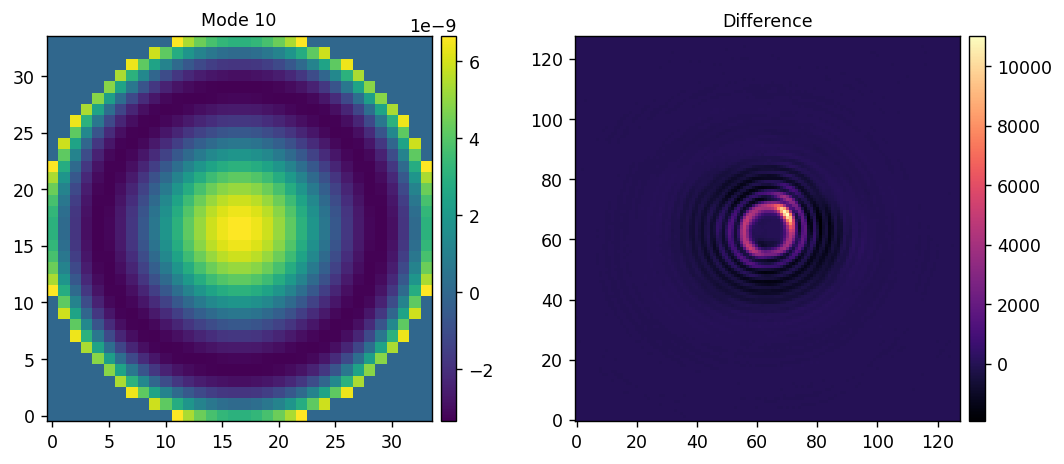

In [28]:
reload(llowfsc)
zer_calib_amp = 3e-9
zer_calib_nframes = 100

zer_response_matrix, zer_response_cube = llowfsc.calibrate_without_fsm(
    camlo_stream, 
    dm_lo_stream, 
    zer_modes, 
    control_mask, 
    amps=zer_calib_amp, 
    NFRAMES=zer_calib_nframes, 
    dm_delay=0.05, 
    plot=True,
)

In [29]:
zer_calib_data = {
    'response_matrix':zer_response_matrix,
    'response_cube':zer_response_cube,
    'modes':zer_modes, 
    'calib_amp':zer_calib_amp,
    'control_mask':control_mask,
    'NFRAMES':zer_calib_nframes,
    'camlo_exp_time':camlo_exp_time,
    'camlo_gain':camlo_gain,
}
utils.save_pickle(llowfsc_data_path/'zernike_calibration.pkl', zer_calib_data)

Saved data to:  /home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250321/llowfsc/zernike_calibration.pkl


In [ ]:
old_calib_path = data_path/f'exp-'/'llowfsc'/'zernike_calibration.pkl'
old_calib_data = utils.load_pickle(old_calib_path)

1


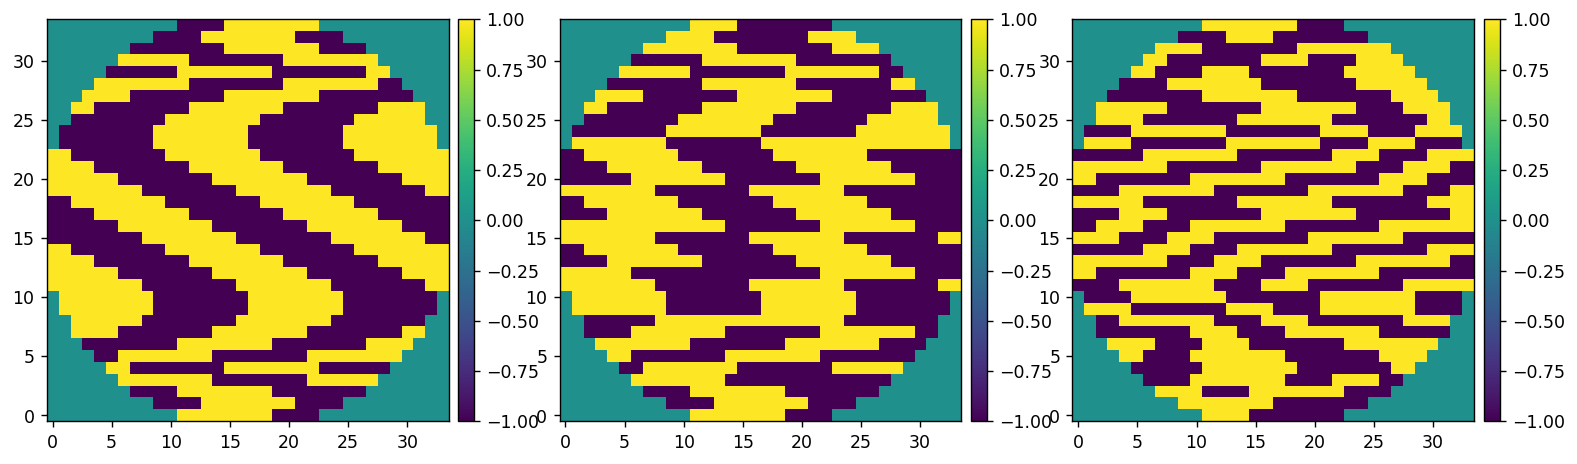

In [ ]:
had_modes = ensure_np_array(utils.create_hadamard_modes(xp.array(dm_mask)))
had_modal_matrix = had_modes.reshape(had_modes.shape[0], -1)
utils.imshow([had_modes[8], had_modes[200], had_modes[300]])

In [16]:
reload(llowfsc)

had_calib_amp = 3e-9
had_calib_nframes = 25

had_response_matrix, had_response_cube = llowfsc.calibrate_without_fsm(
    camlo_stream, 
    dm_lo_stream, 
    had_modes, 
    control_mask, 
    amps=had_calib_amp, 
    NFRAMES=had_calib_nframes, 
    dm_delay=0.02, 
    # plot=True,
)

1


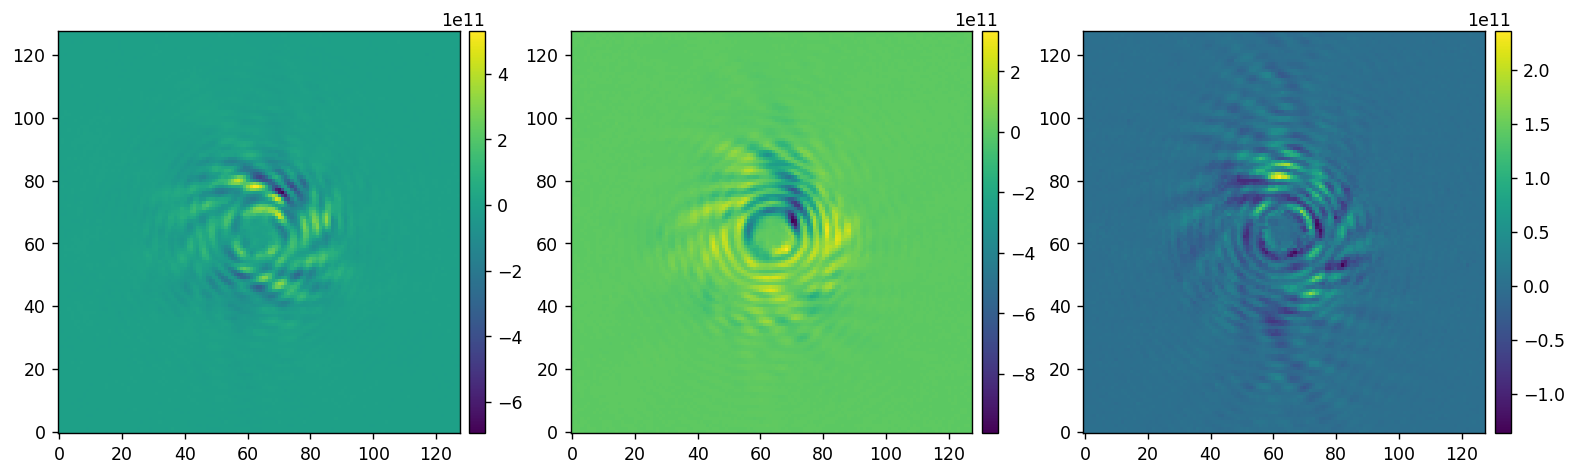

In [ ]:
utils.imshow([had_response_cube[8], had_response_cube[200], had_response_cube[800]])

In [17]:
had_calib_data = {
    'response_matrix':had_response_matrix,
    'response_cube':had_response_cube,
    'modes':had_modes,
    'calib_amp':had_calib_amp,
    'control_mask':control_mask,
    'NLOCAM':had_calib_nframes,
    'camlo_exp_time':camlo_exp_time,
    'camlo_gain':camlo_gain,
}
utils.save_pickle(llowfsc_data_path/'hadamard_calibration.pkl', had_calib_data)

Saved data to:  /home/kianmilani/Projects/scoob-llowfsc/scoob_llowfsc/exp-data/exp-20250321/llowfsc/hadamard_calibration.pkl


# Start the telemetry processes. 

In [ ]:
telem.toggle(1, camlo_name, client0)
telem.toggle(1, camlo_ref_name, client0)
telem.toggle(1, camlo_ref_offset_name, client0)
telem.toggle(1, dm_lo_name, client0)
telem.toggle(1, dm_ho_name, client0)

# Define and run the reference offsetting process.

In [20]:
reload(scoobi)
reload(llowfsc)
reload(utils)

update_freq = 100
interval = 1/update_freq

args = [
    had_response_matrix, 
    had_modal_matrix, 
    control_mask, 
    dm_ho_stream, 
    camlo_ref_offset_stream,
]

ref_offset_process = llowfsc.Process(
    interval, 
    llowfsc.update_ref_offset, 
    args, # the args
)

In [21]:
ref_offset_process.start()

In [63]:
ref_offset_process.cancel()

In [32]:
dm_ho_stream.write(0.00 * had_modes[8])

# Define and run the LLOWFSC process.

In [33]:
lo_cm = ensure_np_array(utils.TikhonovInverse(xp.array(zer_response_matrix), 0))

gain_channel = 'llowfsc_gains'
leak_channel = 'llowfsc_leakage'
scoobi.create_shmim(gain_channel, (Nz_modes, 1))
scoobi.create_shmim(leak_channel, (1, 1)) # yes, it is a 1x1 array, shmims have to be this way

gains_stream = ImageStream(gain_channel)
leak_stream = ImageStream(leak_channel)
gains_stream.write(np.array([2*[0.5] + 8*[0.05],]))
leak_stream.write(np.array([[0.0]]))

In [57]:
reload(llowfsc)
reload(utils)

llowfsc_freq = 50
llowfsc_interval = 1/llowfsc_freq

args = [
    dm_lo_stream,
    camlo_stream,
    camlo_ref_stream,
    camlo_ref_offset_stream,  
    gains_stream,
    leak_stream, 
    lo_cm, 
    zer_modal_matrix, 
    control_mask, 
]

llowfsc_process = llowfsc.Process(
    1/llowfsc_freq, 
    llowfsc.single_iteration, 
    args, # the args
    # kwargs, # the kwargs
)



# Run the LLOWFSC process

In [61]:
# telem.toggle(1, 'camnsv', client0)
# telem.toggle(1, dm_lo_channel, client0)
llowfsc_process.start()

In [62]:
llowfsc_process.cancel()
dm_lo_stream.write(np.zeros(dm_lo_stream.shape))
# telem.toggle(0, 'camnsv', client0)
# telem.toggle(0, dm_lo_channel, client0)

## Adjust leakage and gains

In [58]:
leak_stream.write(np.array([[0.02]]))

In [59]:
gains_stream.write(np.array([2*[0.5] + 8*[0.0]]))

In [60]:
gains_stream.write(np.array([2*[0.5] + 8*[0.05]]))

In [55]:
gains_stream.write(np.array([2*[0.75] + 8*[0.05]]))

In [153]:
gains_stream.write(np.array([2*[0.75] + 3*[0.1] + 5*[0.1]]))

In [ ]:
gains_stream.write(np.array([2*[0.75] + 3*[0.2] + 5*[0.2]]))

# Stop the telemetry processes at the very end of an experiment.

In [ ]:
telem.toggle(0, camlo_name, client0)
telem.toggle(0, camlo_ref_name, client0)
telem.toggle(0, camlo_ref_offset_name, client0)
telem.toggle(0, dm_lo_name, client0)
telem.toggle(0, dm_ho_name, client0)